# Lesson 20/21 K-Nearest Neighbors for Regression

KNN has three important **hyperparameters**:  
- Distance / similarity function  
- The number $k$ of neighbors to make the prediction  
- The procedure for combining the predictions of the $k$ examples.   

<mark> **KNN Algorithm** </mark>  

1. Load data. 
2. Initialize/Specify $K$, the number of nearest neighbors.  
3. For each row in the data set (each sample):
    1. Calculate distance between the query example and the current example from the data.  IE distance between a fixed sample and a neighbor. 
    2. Add the distance and the index of the example to an ordered collection.  This order is determined by the distance.  
4. Sort the ordered collection of distances and indices from smallest to largest (in ascending order) by the distances. 
5. Select the first $K$ entries from the sorted collection.  
6. Get the labels of the selected $K$ entries. These are the response variables / labeled data. 
7. <mark> If this is a regression problem with KNN </mark>, return the **mean of the $K$ labels**. 

## EDA 

This data has a lot of columns / features...  

Appears to not have missing data. 

<mark> It is important to note that you will only be using the energy data </mark> and not training with the rest of the data. "Time" or the "NEXT" variable is the only important factor, not a multi-dimensional approach that uses <mark> time and space </mark>.

This is a **time series problem** so we are going to split this in the T direction by selecting up to a certain percentage of time to look in the past for training, and the "future" for testing. We will also need a **window** for the data training generation, just like we've done before where we select a certain number of values like say 4 in a row to predict 1 future value. 

## KNN Training  

Explore the **KNN hyperparameters**.  

How many neighbors we use to make the prediction and what distances are used to recover them.  

There is a <mark> kd tree </mark> ombines the distances and what data resolution of index that allows us to recover the neighbors.  

Here are the **hyperparameters**:
- `n_neighbors`: number of neighbors to use.
- `weights`: weight function type for prediction.
- `leaf_size`: leaf size passed to this KDtree
- `metric`: metric to use for distance computation.

params	mean_test_score	rank_test_score   
4	{'leaf_size': 5, 'metric': 'l2', 'n_neighbors': 15, 'weights': 'distance'}	-0.004092	1  
2	{'leaf_size': 15, 'metric': 'l2', 'n_neighbors': 5, 'weights': 'distance'}	-0.004382	2  
1	{'leaf_size': 5, 'metric': 'cosine', 'n_neighbors': 25, 'weights': 'uniform'}	-0.006912	3

## Performance Evaluation

The MSEis low, so we should expect this model will work well with other new data from similar sources.   
**MSE**: 0.005197070882242736  

The MAE is low as well:  
**MAE**: 0.032179912582597926  


## Visualize  

<img src="prediction_result.png" width="500">

# Imports

In [1]:
%cd ..

/Users/jaimemerizalde/Desktop/Library/Machine Learning Udemy Course


In [79]:
from Library import data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, HTML

from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit
from skopt import BayesSearchCV
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error


# Get Data

In [8]:
df = data.get_data("Datasets/Energy.csv", index_col=[0])
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,11-01-2016 17:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,11-01-2016 17:10,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,11-01-2016 17:20,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,11-01-2016 17:30,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,11-01-2016 17:40,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## EDA

In [24]:
# Check out variables and means.
df.describe(include="all")

# Is there any missing data?
df.isna().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

## Train Test Split

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from numpy.lib.stride_tricks import sliding_window_view

# Select
e_train = df["Appliances"].iloc[:12000]
e_test = df["Appliances"].iloc[12000:]

# Normalize
scaler = MinMaxScaler()
e_train_s = scaler.fit_transform(e_train.to_numpy().reshape(-1,1))
e_test_s = scaler.fit_transform(e_test.to_numpy().reshape(-1,1))

# Create Windows
w = 4
windows_train = sliding_window_view(e_train_s, w + 1, axis=0).copy()
X_train_w =  windows_train.squeeze()[:, :-1]
y_train_w = windows_train.squeeze()[:, -1]

windows_test = sliding_window_view(e_test_s, w + 1, axis=0)
X_test_w = windows_test.squeeze()[:, :-1]
y_test_w = windows_test.squeeze()[:, -1]

# KNN Training

In [61]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit
from skopt import BayesSearchCV
from sklearn.metrics import make_scorer, mean_squared_error

knn = KNeighborsRegressor()

params = {
    "n_neighbors": [1, 3, 5, 7, 11, 15, 20, 25],
    "weights": ["distance", "uniform"],
    "leaf_size": [1, 5, 10, 15, 20, 25, 30],
    "metric": ["l2", "l1", "cosine"]
}

knn_bscv = BayesSearchCV(
    knn, params,
    cv=TimeSeriesSplit(n_splits=5, gap=w+1),
    n_iter=5,
    scoring=make_scorer(mean_squared_error, greater_is_better=False), 
    refit=True,  n_jobs=-1, random_state=0
)

knn_bscv.fit(X_train_w, y_train_w)


BayesSearchCV(cv=TimeSeriesSplit(gap=5, max_train_size=None, n_splits=5, test_size=None),
              estimator=KNeighborsRegressor(), n_iter=5, n_jobs=-1,
              random_state=0,
              scoring=make_scorer(mean_squared_error, greater_is_better=False, response_method='predict'),
              search_spaces={'leaf_size': [1, 5, 10, 15, 20, 25, 30],
                             'metric': ['l2', 'l1', 'cosine'],
                             'n_neighbors': [1, 3, 5, 7, 11, 15, 20, 25],
                             'weights': ['distance', 'uniform']})

# Visualize

In [76]:
from IPython.display import display, HTML

df_html = pd.DataFrame(knn_bscv.cv_results_)
df_html = df_html.loc[:, ["params", "mean_test_score", "rank_test_score"]]

show_html(df_html.sort_values(by="rank_test_score").head().to_html())  



,params,mean_test_score,rank_test_score
4,"{'leaf_size': 5, 'metric': 'l2', 'n_neighbors': 15, 'weights': 'distance'}",-0.004092,1
2,"{'leaf_size': 15, 'metric': 'l2', 'n_neighbors': 5, 'weights': 'distance'}",-0.004382,2
1,"{'leaf_size': 5, 'metric': 'cosine', 'n_neighbors': 25, 'weights': 'uniform'}",-0.006912,3
0,"{'leaf_size': 15, 'metric': 'cosine', 'n_neighbors': 11, 'weights': 'uniform'}",-0.007173,4
3,"{'leaf_size': 5, 'metric': 'cosine', 'n_neighbors': 7, 'weights': 'distance'}",-0.007213,5


# Performance Evaluation

0.005197070882242736
0.032179912582597926


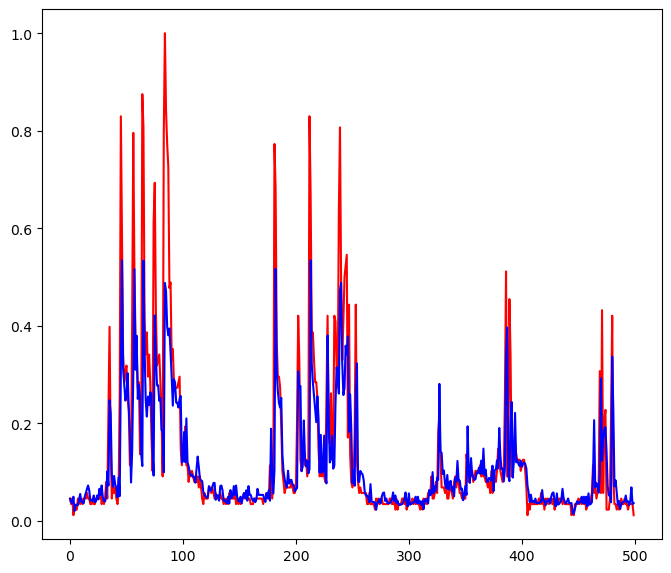

In [87]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

y_pred = knn_bscv.predict(X_test_w)

print(mean_squared_error(y_pred, y_test_w))
print(mean_absolute_error(y_pred, y_test_w))

plt.figure(figsize=(8, 8 / 1.1618))

# Plot several first 500 values.
plt.plot(y_test_w[:500], "r")
plt.plot(y_pred[:500], "b")


In [82]:
y_pred

array([0.04485981, 0.03862928, 0.03551402, ..., 0.16972114, 0.3512295 ,
       0.31829571])